In [1]:
# 2.다중 클래스 분류(Multi-class Classification) 실습
# - 3개 클래스 분류
# - 학습 결과 저장
# - 저장된 모델/스케일러/학습 이력 불러오기
# - 신규 데이터 예측
# - 학습결과 및 예측결과 시각화

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, auc
from sklearn.datasets import load_wine           # 와인 데이터 셋 읽어오기
import joblib                                     # 파이썬 객체 저장을 위한 joblib
import tensorflow as tf                           # 딥러닝 프레임워크

# 케라스의 모델 저장 및 로드 기능을 사용하기 위한 필요 모듈
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense, Dropout             # 레이어 구성 및 드랍아웃(블랙박스의 특정 뉴런 제거시 성능 향상 이유 X) 적용 라이브러리
from tensorflow.keras.callbacks import EarlyStopping           # 학습 조기종료 콜백 라이브러리
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

In [6]:
# 1. 데이터셋 준비
data = load_wine()
X = data.data
y = data.target

feature_names = data. feature_names
df = pd.DataFrame(X, columns=feature_names)

df['target'] = y

print('전체 데이터 shape: ', df.shape)

df.head()

전체 데이터 shape:  (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


In [7]:
# 2. 학습용/테스트용 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(
  X, y, test_size=0.2, random_state=42, stratify=y
)

In [8]:
# 3. 스케일링
scaler = StandardScaler()                           # 스케일러 객체 생성
X_train_scaled = scaler.fit_transform(X_train)      # 학습 데이터 기준으로  평균과 표준편차를 학습후 반환
X_test_scaled = scaler.transform(X_test)

In [ ]:
# 4. one-hot 인코드 수행 (정답 개수에 따라 확률이 출력되면 학률이 가장 높은 클래스만 1로 변환 나머진 0으로 변환)
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

In [10]:
# 5. 모델 정의
model = Sequential()              # 모델 프레임 생성

# 첫 번째 은닉층 추가
model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))         # 과적합 방지를 위해 드롭아웃 20% 적용

# 두 번째 은닉층 추가
model.add(Dense(32, activation='relu'))

# 출력층 추가
model.add(Dense(3, activation='softmax'))              # 출력층은 정답의 개수에 따라

/home/pc/anaconda3/envs/ai/lib/python3.10/site-packages/keras/src/layers/core/dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1787280400.919145   57989 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787280400.950433   57989 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [ ]:
# 6. 모델 컴파일 설정

model.compile(
  optimizer='adam',                         # 학습은 adam
  loss = 'categorical_crossentropy',        # 손실함수는 categorical_crossentropy 적용 (멀티 클래스)
  metrics = ['accuracy']                    # 평가지표는 accuracy 사용
)

# 조기 종료 콜백 정의
early_stop = EarlyStopping(
  monitor='val_loss',                   # val_loss 값이 더이상 줄어들지 않는다면
  patience=10,                          
  restore_best_weights=True
)

In [12]:
# 7. 모델 학습
# 모델을 학습하고, history 객체에 학습 과정을 저장
history = model.fit(
  X_train_scaled,               # 입력데이터 X
  y_train_cat,                      # 정답데이터 y
  validation_split=0.2,           # 검증 20%
  epochs=100,                   # 전체 학습 수 100번
  batch_size=16,                # 한번에 도는 학습 1회 사이클 16번
  callbacks=[early_stop]        # 조기종료 콜백 정의
)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.6372 - loss: 0.8898 - val_accuracy: 0.3793 - val_loss: 0.9475
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7788 - loss: 0.6766 - val_accuracy: 0.6897 - val_loss: 0.7766
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8761 - loss: 0.5882 - val_accuracy: 0.8966 - val_loss: 0.6381
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9381 - loss: 0.4788 - val_accuracy: 0.9655 - val_loss: 0.5169
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9558 - loss: 0.4038 - val_accuracy: 1.0000 - val_loss: 0.4116
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9558 - loss: 0.3031 - val_accuracy: 1.0000 - val_loss: 0.3265
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9912 - loss: 0.2680 - val_accuracy: 1.0000 - val_loss: 0.2578
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9912 - loss: 0.1947 - val_accuracy: 1.0000 - val_loss: 0.2026

In [14]:
# 8. 모델 평가
# 테스트 데이터(20%)에 대한 손실과 정확도를 평가
test_loss, test_acc = model.evaluate(X_test_scaled, y_test_cat, verbose=0)

# 평가 결과 출력
print('테스트 손실: ', test_loss)
print('테스트 정확도 : ', test_acc)

# 에측확률
y_prob = model.predict(X_test_scaled)

# 가장 확률이 높은 클래스를 선택
y_pred = np.argmax(y_prob, axis=1)

# 정확도 계산
acc = accuracy_score(y_test, y_pred)

# confusion matrix 계산
cm = confusion_matrix(y_test, y_pred)

# 분류 리포트 출력
print('정확도: ', acc)
print('confusion_matrix: \n', cm)
print('분류 리포트 : \n', classification_report(y_test, y_pred))

테스트 손실:  0.10817457735538483
테스트 정확도 :  0.9444444179534912
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step
정확도:  0.9444444444444444
confusion_matrix: 
 [[12  0  0]
 [ 0 14  0]
 [ 0  2  8]]
분류 리포트 : 
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       0.88      1.00      0.93        14
           2       1.00      0.80      0.89        10

    accuracy                           0.94        36
   macro avg       0.96      0.93      0.94        36
weighted avg       0.95      0.94      0.94        36



In [15]:
# 9. 학습결과 저장
# 모델을 파일로 저장
model.save('./model/MultiClass_Classification.h5')    # 또는 MultiClass_Classification.keras

# 스케일러를 파일로 저장
joblib.dump(scaler, './model/MultiClass_Classification.pkl')

# 학습이력을 데이터 프레임으로 변환
history_df = pd.DataFrame(history.history)

# 학습이력을 csv 파일로 저장
history_df.to_csv('./model/MultiClass_Classification.csv', index=False)

print("멀티클래스 분류 모델, 스케일러, 학습이력 저장 완료")

멀티클래스 분류 모델, 스케일러, 학습이력 저장 완료


In [17]:
# 9. 저장된 결과 읽어 오기  (프론트엔드에서 실행되는 로직이라고 이해하면 된다)

# 저장된 모델을 다시 읽어오기
loaded_model = tf.keras.models.load_model('./model/MultiClass_Classification.h5')

# 저장된 스케일러를 다시 읽어오기
loaded_scaler = joblib.load('./model/MultiClass_Classification.pkl')

In [24]:
# 10. 신규 데이터 예측

# 학습하지 않은 테스트데이터 중 5개를 신규 데이터로 예측 수행
new_data = X_test[:20]

# 신규 데이터 스케일링 처리
new_data_scaled = loaded_scaler.transform(new_data)

# 신규 데이터 예측 확률 계산
new_prob = loaded_model.predict(new_data_scaled)

# 가장 확률이 높은 클래스를 선택
new_pred = np.argmax(new_prob, axis=1)

# 결과 출력
for i in range(len(new_data)):
  print(f"{i + 1}번 샘플 - 예측확률: {new_prob[i]}, 예측클래스: {new_pred[i]}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1번 샘플 - 예측확률: [1.0000000e+00 6.4366872e-09 2.8467246e-08], 예측클래스: 0
2번 샘플 - 예측확률: [0.00116846 0.7275279  0.27130365], 예측클래스: 1
3번 샘플 - 예측확률: [9.9999237e-01 3.1602849e-06 4.3855503e-06], 예측클래스: 0
4번 샘플 - 예측확률: [9.4515741e-02 9.0533036e-01 1.5391626e-04], 예측클래스: 1
5번 샘플 - 예측확률: [3.4823366e-05 9.9995673e-01 8.4185303e-06], 예측클래스: 1
6번 샘플 - 예측확률: [9.9999964e-01 1.2536303e-07 2.4641969e-07], 예측클래스: 0
7번 샘플 - 예측확률: [9.9999905e-01 3.9027068e-08 9.1301274e-07], 예측클래스: 0
8번 샘플 - 예측확률: [7.1432261e-04 9.9928397e-01 1.7162567e-06], 예측클래스: 1
9번 샘플 - 예측확률: [7.6004122e-05 9.9936420e-01 5.5975874e-04], 예측클래스: 1
10번 샘플 - 예측확률: [2.2177727e-04 1.0402480e-05 9.9976784e-01], 예측클래스: 2
11번 샘플 - 예측확률: [7.4898766e-04 9.9868923e-01 5.6184107e-04], 예측클래스: 1
12번 샘플 - 예측확률: [0.00493608 0.00642077 0.9886432 ], 예측클래스: 2
13번 샘플 - 예측확률: [1.0000000e+00 8.7312069e-09 4.2159577e-08], 예측클래스: 0
14번 샘플 - 예측확률: [0.00251323 0.86327267 0.13421406], 예측클래스: 1
15번 샘플 - 예측확률: [1.0000000e+00 6.

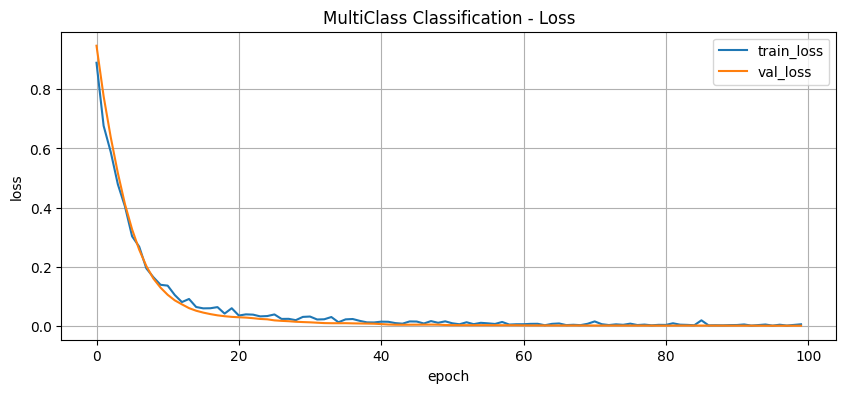

In [25]:
# 12. 시각화 결과 확인

# 학습, Loss 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('MultiClass Classification - Loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.grid(True) # 그래프 격자 표시
plt.show()

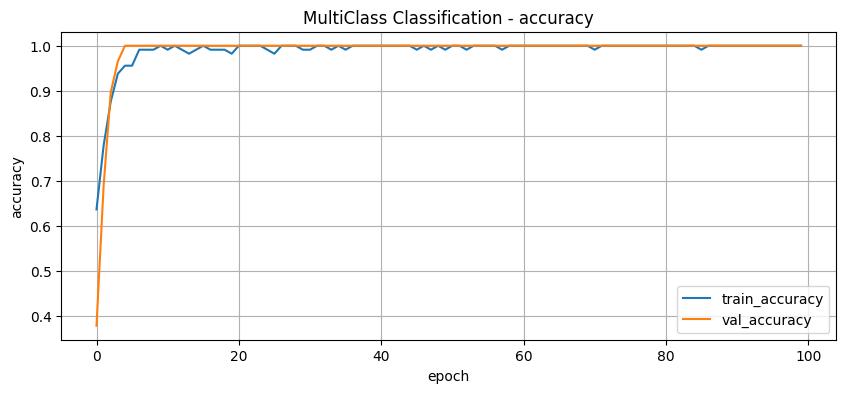

In [21]:
# 13. 학습, 정확도 결과 시각화
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('MultiClass Classification - accuracy')
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend()
plt.grid(True) # 그래프 격자 표시
plt.show()

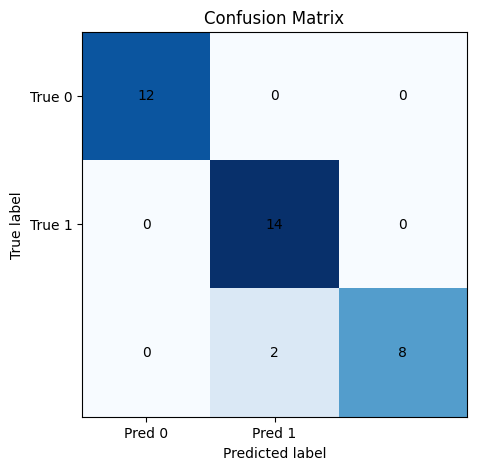

In [26]:
# 13. confusion matrix A/2t2/
plt.figure(figsize=(6,5))
plt.imshow(cm, cmap='Blues')
plt.title('Confusion Matrix')

# ×축과 y축 눈금 설정
plt.xticks(([0,1]), ['Pred 0', 'Pred 1'])
plt.yticks(([0,1]), ['True 0', 'True 1'])

# cm 내부에 숫자 표시
for i in range(cm.shape[0]):
  for j in range(cm.shape[1]):
    plt.text(j, i, cm[i, j], ha='center', va='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.show()

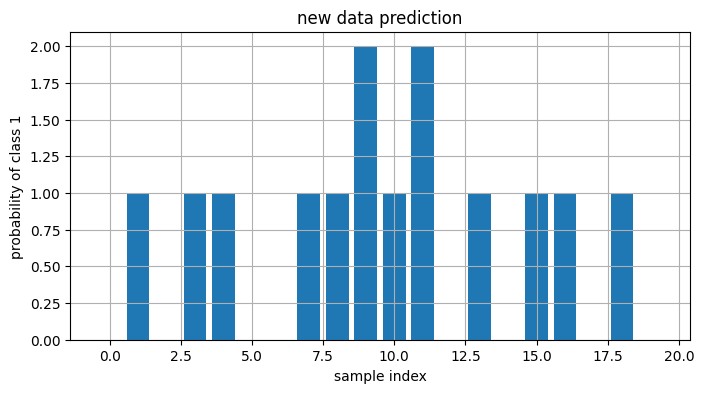

In [27]:
plt.figure(figsize=(8,4))
plt.bar(range(len(new_pred)), new_pred)

plt.title('new data prediction')
plt.xlabel('sample index')
plt.ylabel('probability of class 1')

plt.grid(True)
plt.show()